In [ ]:
import gdown
import pandas as pd

file_id = "1hkUBo5v7WIz8InkUCET_M_IAh0KqtLHb"
url = f"https://drive.google.com/uc?id={file_id}"
output = "data.xlsx"  # Asegurar que la extensión coincida con el tipo de archivo


# Descargar el archivo desde Google Drive
gdown.download(url, output, quiet=False)

# Leer el archivo como DataFrame
df = pd.read_excel(output)
df.head()


Downloading...
From: https://drive.google.com/uc?id=1hkUBo5v7WIz8InkUCET_M_IAh0KqtLHb
To: /content/data.xlsx
100%|██████████| 9.71M/9.71M [00:00<00:00, 235MB/s]


,Período,Hacienda,Nombre,Zona,Tenencia,Suerte,Suelo,Area Neta,Dist Km,Variedad,...,Humedad Rel Media Ciclo,Oscilacion Temp Med 0-3,Oscilacion Temp Ciclo,Sum Oscilacion Temp Ciclo,Radicion Solar 0-3,Radiacion Solar Ciclo,Precipitacion 0_3,Precipitacion Ciclo,Evaporacion 0-3,Evaporacion Ciclo
0,201701,80493,LA CONCHA,IP02,51.0,002A,CANTARINA,6.00,4.3,CC85-92,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,201701,81284,UKRANIA INCAUCA,IP05,81.0,039B,NaN,1.45,NaN,CC85-92,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,201701,80203,EL AMPARO SAA,IP05,31.0,007,CORINTIAS,8.24,23.0,CC01-1228,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,201701,81380,SAN JUDAS INCAUCA,IP05,82.0,013A,NaN,1.05,66.5,CC01-1940,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,201701,80298,JAVA,IP06,31.0,025A,GALPON,4.53,17.0,RB73-2223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Importar Librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split # Import the train_test_split function
from sklearn.linear_model import LinearRegression # Import the LinearRegression class
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error  # Import r2_score, mean_absolute_error, and mean_squared_error

In [ ]:
# Seleccionar todas las columnas numéricas para el análisis
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
df_numeric = df[numeric_columns].copy()

In [ ]:
# Resumen estadístico
descriptive_stats = df_numeric.describe()
print("Resumen Estadístico:\n", descriptive_stats)

Resumen Estadístico:
              Período      Hacienda      Tenencia     Area Neta       Dist Km  \
count   21027.000000  21027.000000  21026.000000  21027.000000  21022.000000   
mean   202039.708708  80679.334427     46.448730      8.642948     25.311806   
std       216.642895    590.030150     21.513498      7.049533     18.237344   
min    201701.000000  80100.000000     11.000000      0.004000      1.100000   
25%    201812.000000  80247.000000     31.000000      3.310000     12.000000   
50%    202010.000000  80453.000000     51.000000      7.000000     21.900000   
75%    202209.000000  81104.000000     51.000000     12.075000     32.700000   
max    202407.000000  82557.000000     91.000000     65.000000    155.000000   

       Cod.Estado #  Edad Ult Cos  Destino 1=Semilla  Cod. T.Cultivo  \
count  21027.000000   21027.00000       21027.000000    21025.000000   
mean       4.261806      13.01111           0.013982        1.036100   
std        4.111935       1.97907        

In [ ]:
# Valores faltantes
missing_values = df_numeric.isnull().sum()
print("\nValores Faltantes:\n", missing_values)


Valores Faltantes:
 Período                      0
Hacienda                     0
Tenencia                     1
Area Neta                    0
Dist Km                      5
                         ...  
Radiacion Solar Ciclo    16497
Precipitacion 0_3        16497
Precipitacion Ciclo      16497
Evaporacion 0-3          16497
Evaporacion Ciclo        16497
Length: 67, dtype: int64


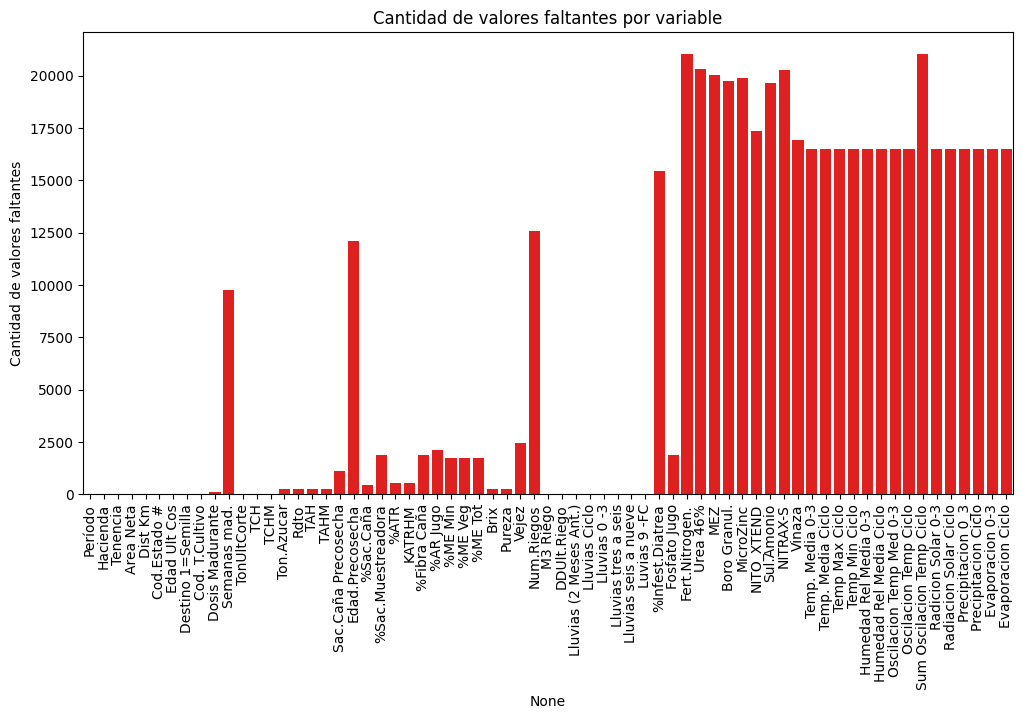

In [ ]:
# Gráfico de cantidad de valores faltantes
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, color='red')
plt.xticks(rotation=90)
plt.ylabel("Cantidad de valores faltantes")
plt.title("Cantidad de valores faltantes por variable")
plt.show()

In [ ]:
# Eliminar variables con más del 50% de datos faltantes
threshold = 0.5  # 50%
missing_ratio = df_numeric.isnull().mean()
print(missing_ratio)
df_analysis = df_numeric.loc[:, missing_ratio < threshold]
df_analysis.columns


Período                  0.000000
Hacienda                 0.000000
Tenencia                 0.000048
Area Neta                0.000000
Dist Km                  0.000238
                           ...   
Radiacion Solar Ciclo    0.784563
Precipitacion 0_3        0.784563
Precipitacion Ciclo      0.784563
Evaporacion 0-3          0.784563
Evaporacion Ciclo        0.784563
Length: 67, dtype: float64


Index(['Período', 'Hacienda', 'Tenencia', 'Area Neta', 'Dist Km',
       'Cod.Estado #', 'Edad Ult Cos', 'Destino 1=Semilla', 'Cod. T.Cultivo',
       'Dosis Madurante', 'Semanas mad.', 'TonUltCorte', 'TCH', 'TCHM',
       'Ton.Azucar', 'Rdto', 'TAH', 'TAHM', 'Sac.Caña Precosecha', '%Sac.Caña',
       '%Sac.Muestreadora', '%ATR', 'KATRHM', '%Fibra Caña', '%AR Jugo',
       '%ME Min', '%ME Veg', '%ME Tot', 'Brix', 'Pureza', 'Vejez', 'M3 Riego',
       'DDUlt.Riego', 'Lluvias (2 Meses Ant.)', 'Lluvias Ciclo',
       'Lluvias 0 -3', 'Lluvias tres a seis', 'Lluvias seis a nueve',
       'Luvias 9 -FC', 'Fosfato Jugo'],
      dtype='object')

In [ ]:
# Análisis de variables categóricas
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
df_categorical = df[categorical_columns].copy()

In [ ]:
# Calcular proporción de valores faltantes en variables categóricas
missing_ratio_categorical = df_categorical.isnull().mean()

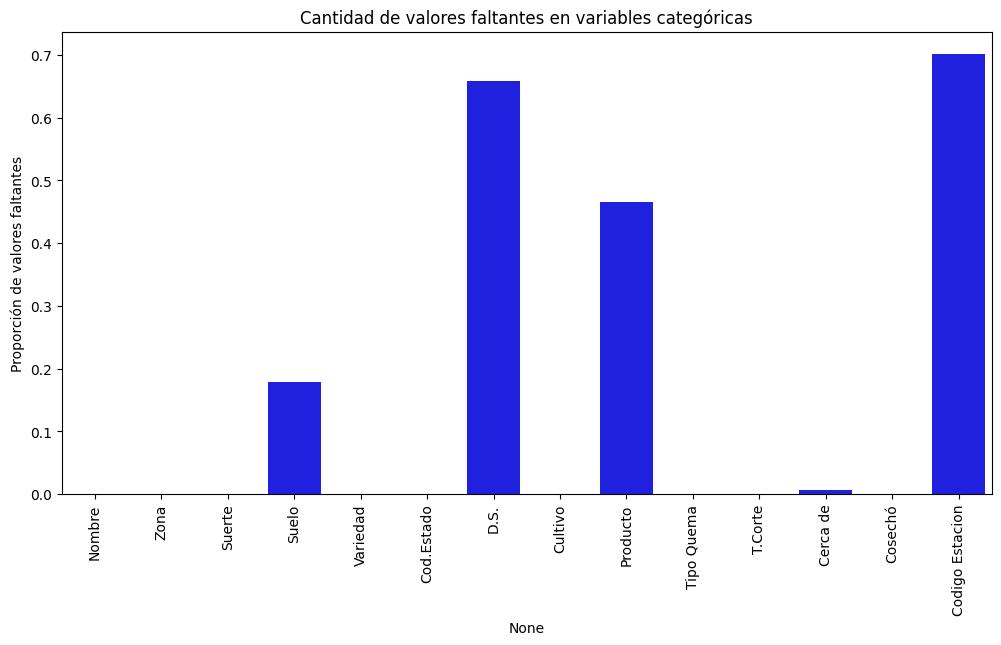

In [ ]:
# Gráfico de cantidad de valores faltantes en variables categóricas
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_ratio_categorical.index, y=missing_ratio_categorical.values, color='blue')
plt.xticks(rotation=90)
plt.ylabel("Proporción de valores faltantes")
plt.title("Cantidad de valores faltantes en variables categóricas")
plt.show()

In [ ]:
# Eliminar variables categóricas con más del 50% de datos faltantes
df_categorical = df_categorical.loc[:, missing_ratio_categorical < threshold]
df_categorical.columns

Index(['Nombre', 'Zona', 'Suerte', 'Suelo', 'Variedad', 'Cod.Estado',
       'Cultivo', 'Producto', 'Tipo Quema', 'T.Corte', 'Cerca de', 'Cosechó'],
      dtype='object')

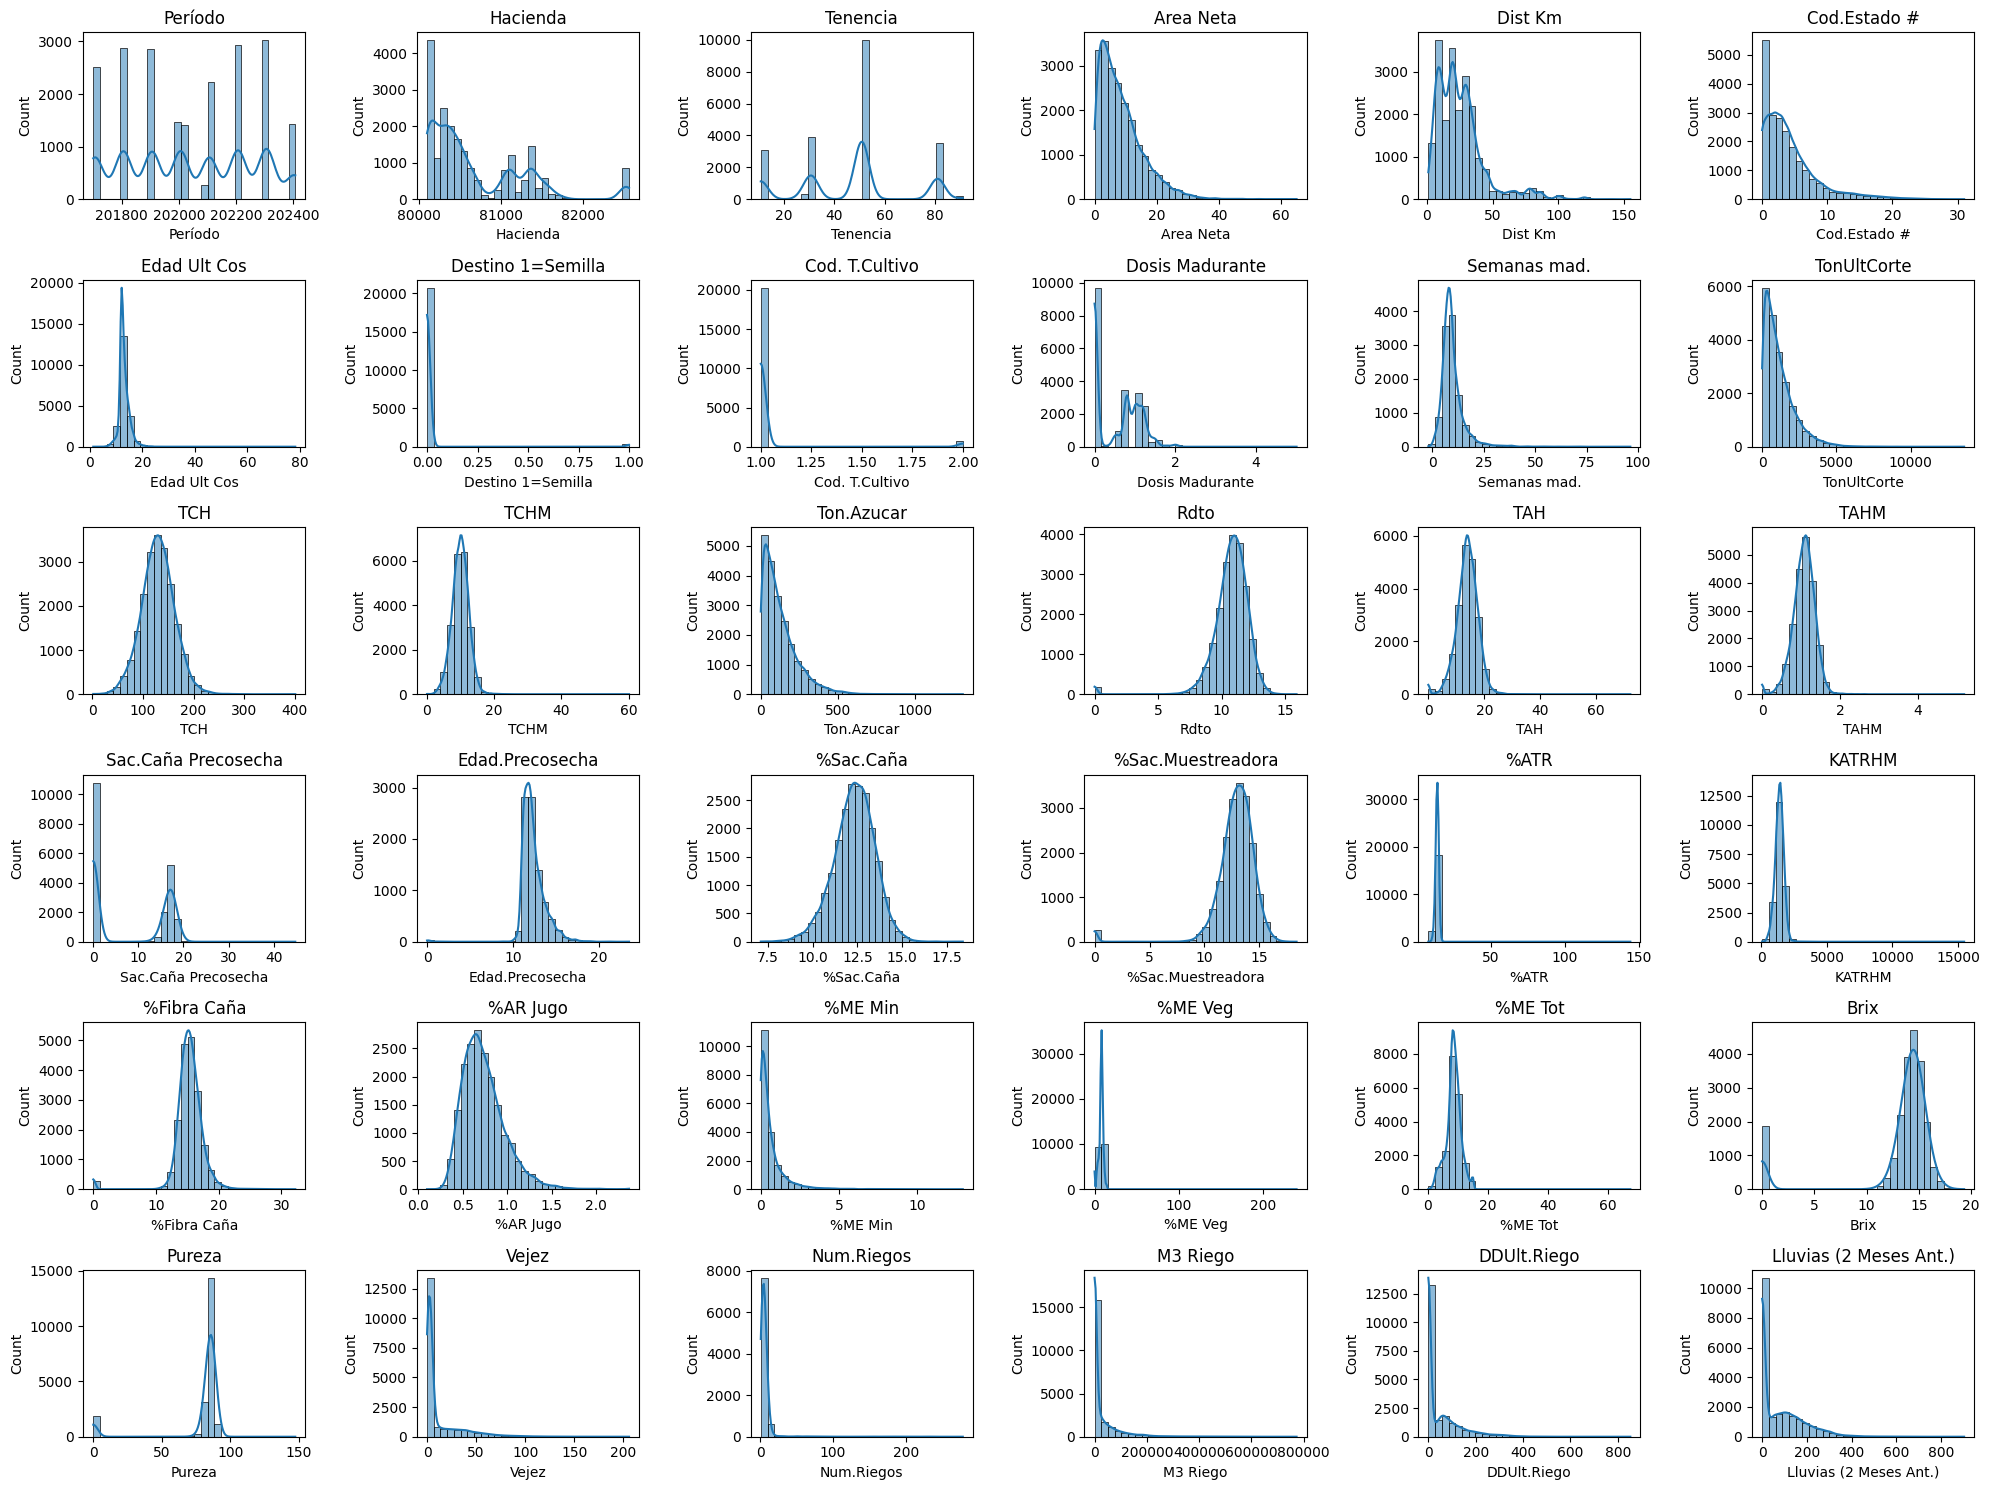

In [ ]:
# Análisis de distribución antes de la imputación
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(20, 15))
axes = axes.flatten()
for i, col in enumerate(df_numeric.columns[:36]):  # Limitar a 36 variables por claridad
    sns.histplot(df_numeric[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
#plt.suptitle("Distribución de Variables Numéricas Antes de la Imputación", fontsize=16)
plt.show()



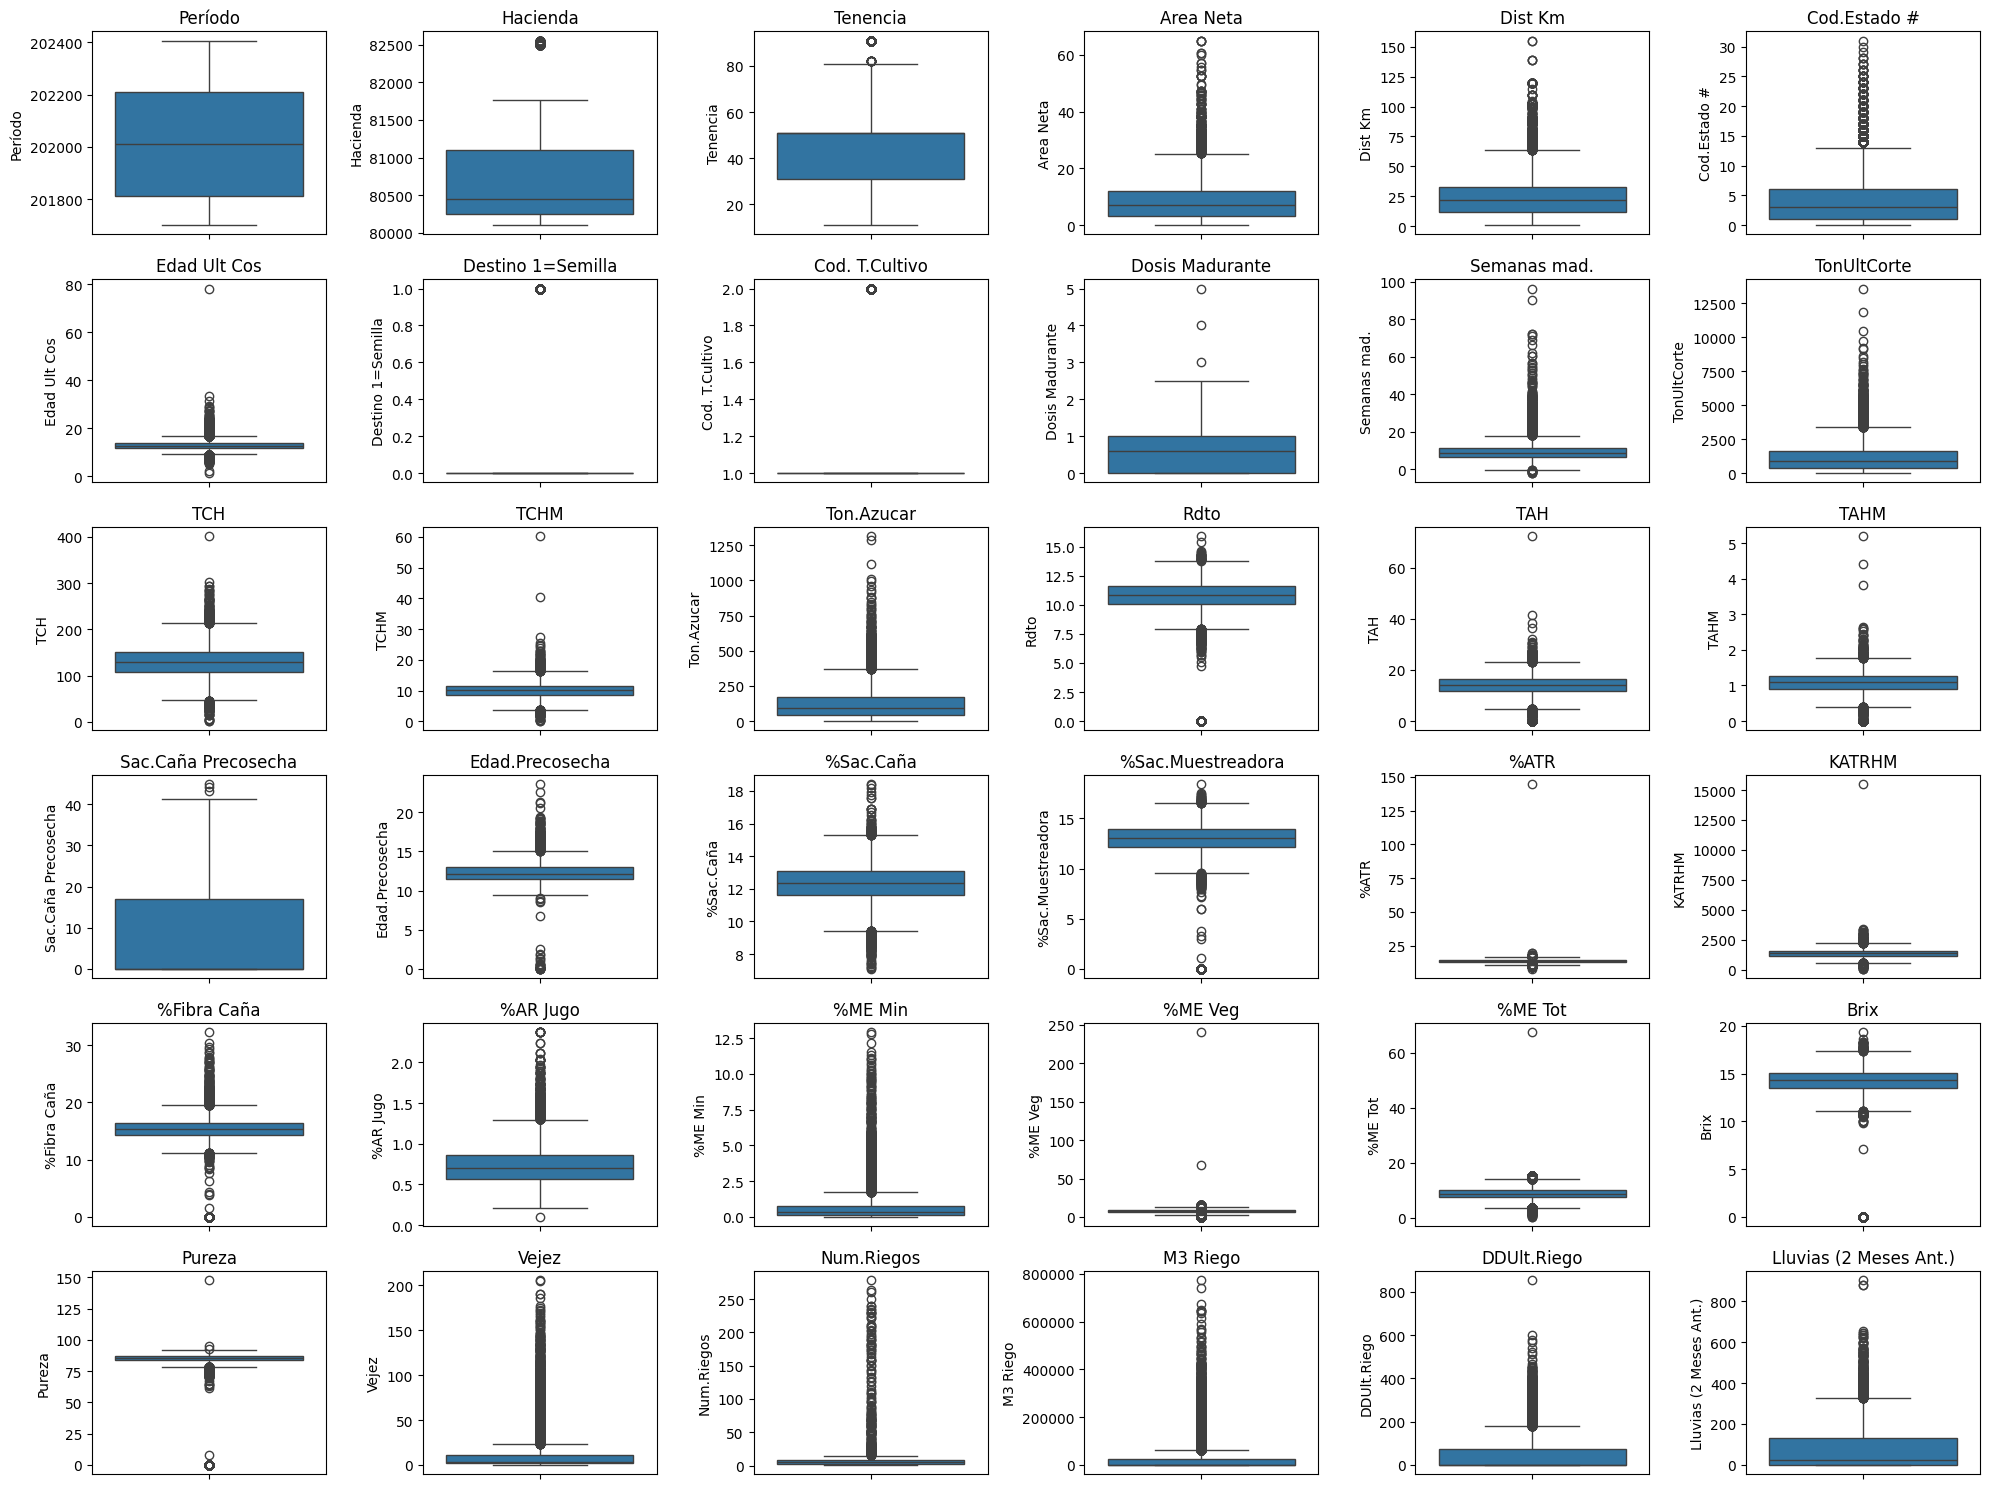

In [ ]:
# Boxplots antes de la imputación para analizar outliers
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(20, 15))
axes = axes.flatten()
for i, col in enumerate(df_numeric.columns[:36]):  # Limitar a 36 variables por claridad
    sns.boxplot(y=df_numeric[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()


In [ ]:
# Comparación entre media y mediana antes de imputar
median_values = df_numeric.median()
mean_values = df_numeric.mean()
comparison_df = pd.DataFrame({"Media": mean_values, "Mediana": median_values})
print("\nComparación entre Media y Mediana:\n", comparison_df)


Comparación entre Media y Mediana:
                                Media    Mediana
Período                202039.708708  202010.00
Hacienda                80679.334427   80453.00
Tenencia                   46.448730      51.00
Area Neta                   8.642948       7.00
Dist Km                    25.311806      21.90
...                              ...        ...
Radiacion Solar Ciclo     438.344500     439.14
Precipitacion 0_3         298.258587     296.90
Precipitacion Ciclo      1209.462980    1181.15
Evaporacion 0-3           442.941369     440.95
Evaporacion Ciclo        1912.479868    1885.20

[67 rows x 2 columns]


In [ ]:
# Imputar valores faltantes en variables numéricas con la mediana
imputer_numeric = SimpleImputer(strategy="median")

# Fit and transform on only numeric columns
df_numeric_imputed = imputer_numeric.fit_transform(df_numeric)

# Get the columns used for imputation (this might be different from df_numeric.columns)
imputed_columns = df_numeric.columns[~df_numeric.isnull().all()]

# Create a new DataFrame with the imputed values and original column names
df_numeric_imputed = pd.DataFrame(df_numeric_imputed, columns=imputed_columns, index=df_numeric.index)

# Update the original DataFrame with the imputed values
# Only update the columns that were imputed
df_numeric[imputed_columns] = df_numeric_imputed

/usr/local/lib/python3.11/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['Fert.Nitrogen.' 'Sum Oscilacion Temp Ciclo']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [ ]:
# Imputar valores faltantes en variables categóricas con la moda
imputer_cat = SimpleImputer(strategy="most_frequent")
df_categorical.iloc[:, :] = imputer_cat.fit_transform(df_categorical)

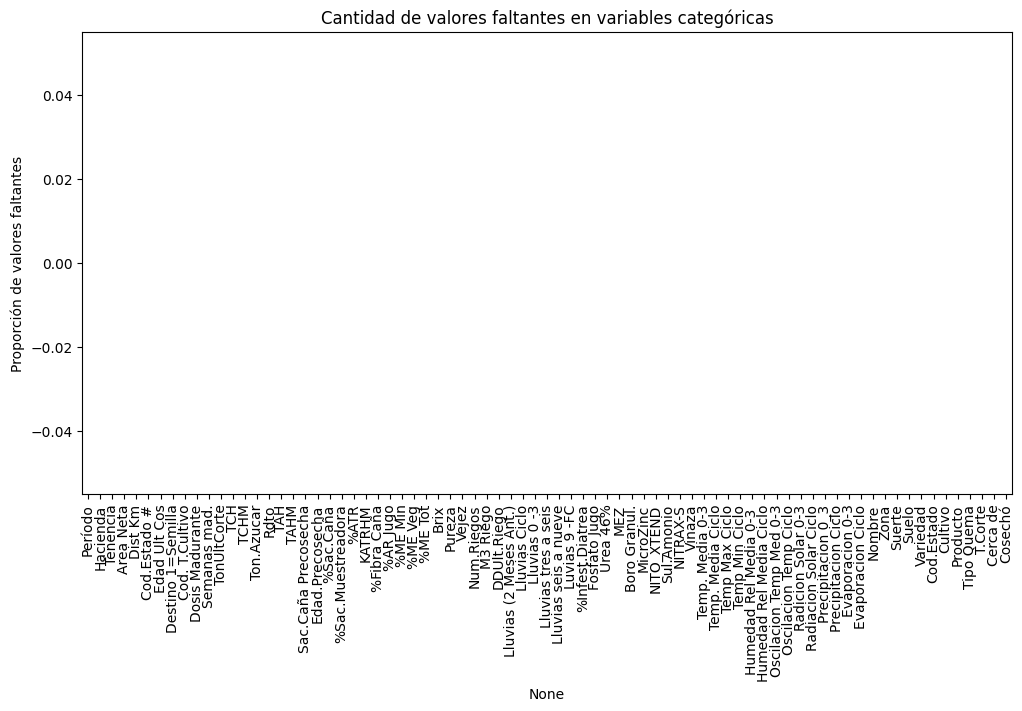

In [ ]:
# Unir las variables después de la imputación
df_model = pd.concat([df_numeric_imputed, df_categorical], axis=1)
df_model.isnull().sum()
missing_ratio_model = df_model.isnull().mean()
# Gráfico de cantidad de valores faltantes en variables categóricas
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_ratio_model.index, y=missing_ratio_model.values, color='blue')
plt.xticks(rotation=90)
plt.ylabel("Proporción de valores faltantes")
plt.title("Cantidad de valores faltantes en variables categóricas")
plt.show()

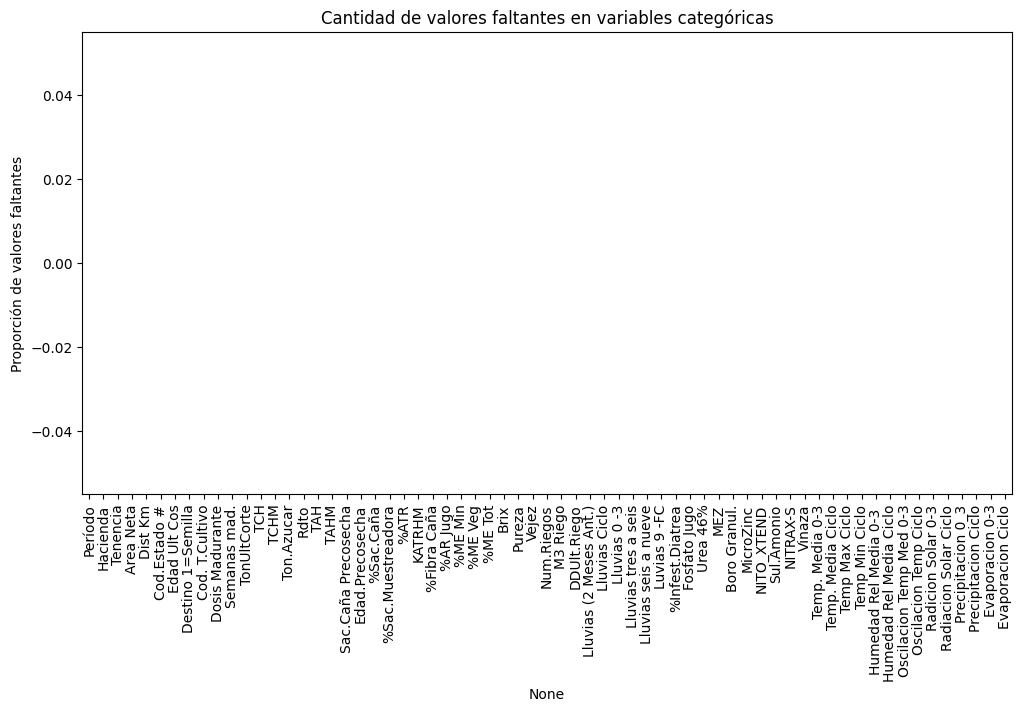

In [ ]:
df_model = df_numeric_imputed
missing_ratio_model = df_model.isnull().mean()
# Gráfico de cantidad de valores faltantes en variables categóricas
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_ratio_model.index, y=missing_ratio_model.values, color='blue')
plt.xticks(rotation=90)
plt.ylabel("Proporción de valores faltantes")
plt.title("Cantidad de valores faltantes en variables categóricas")
plt.show()

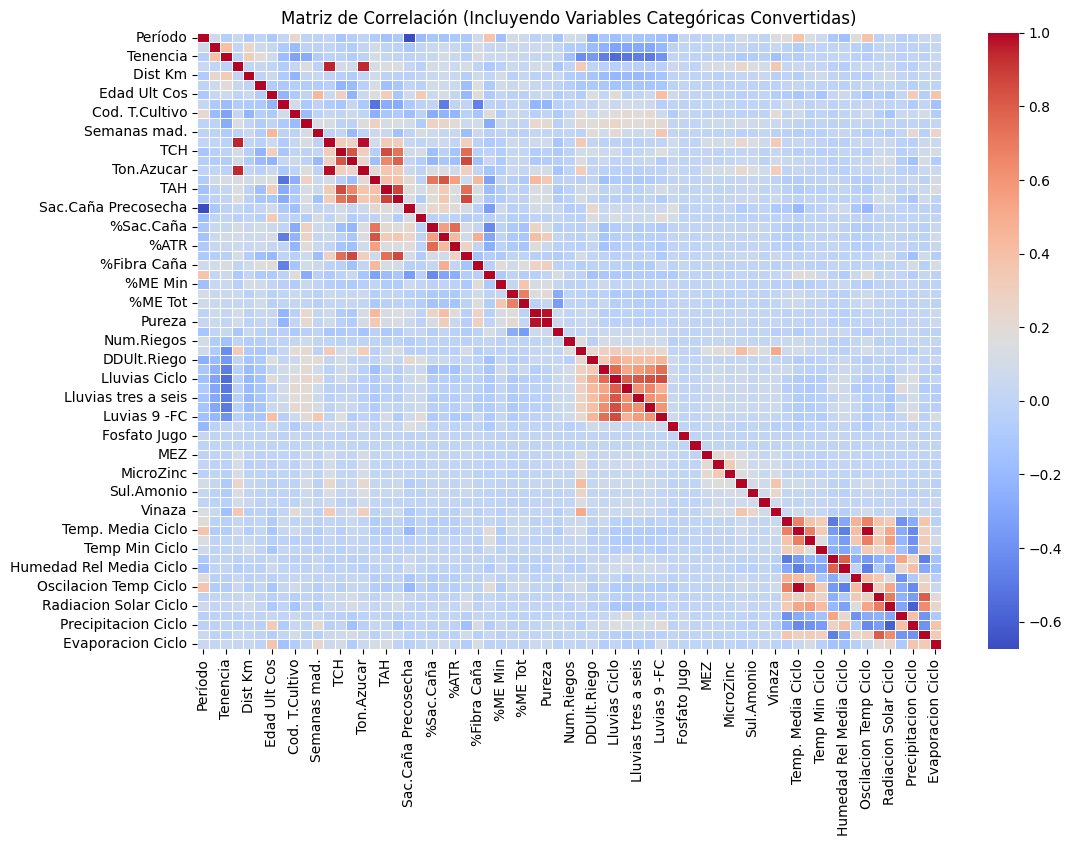

In [ ]:
# Matriz de correlación para todas las variables (numéricas y categóricas convertidas)
correlation_matrix = df_model.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Matriz de Correlación (Incluyendo Variables Categóricas Convertidas)")
plt.show()

In [ ]:
# Selección de variables relevantes para TCH y %Sac.Caña
corr_tch = df_model.corr()["TCH"].sort_values(ascending=False)
corr_sac_cana = df_model.corr()["%Sac.Caña"].sort_values(ascending=False)

In [ ]:
# Filtrar variables con correlación significativa
selected_features_tch = corr_tch[abs(corr_tch) > 0.3].index.tolist()
selected_features_sac_cana = corr_sac_cana[abs(corr_sac_cana) > 0.3].index.tolist()

<ipython-input-60-73e26ca16d11>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=selected_features_tch, y=corr_tch[selected_features_tch], palette="coolwarm")


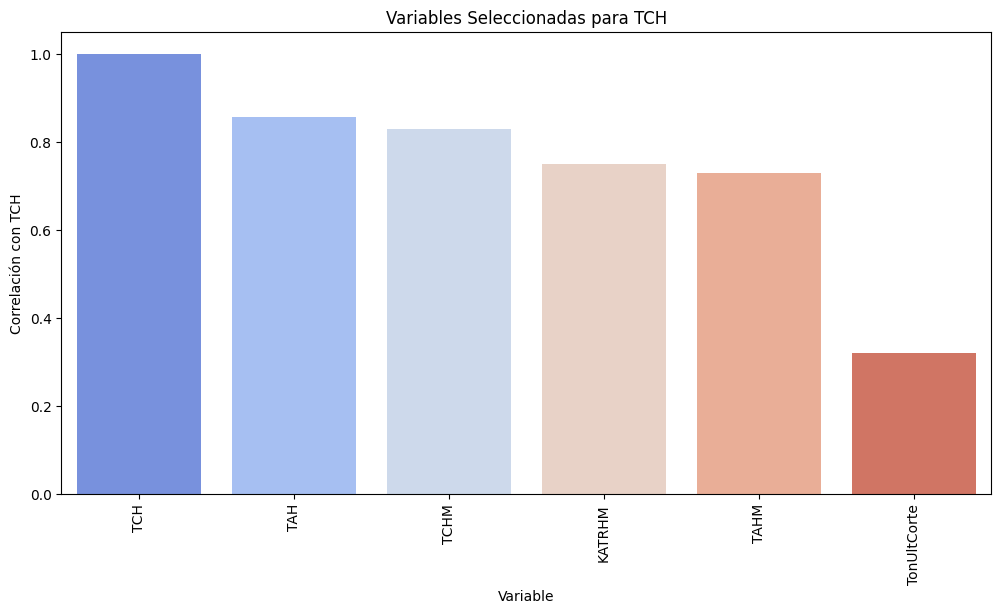

<ipython-input-60-73e26ca16d11>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=selected_features_sac_cana, y=corr_sac_cana[selected_features_sac_cana], palette="coolwarm")


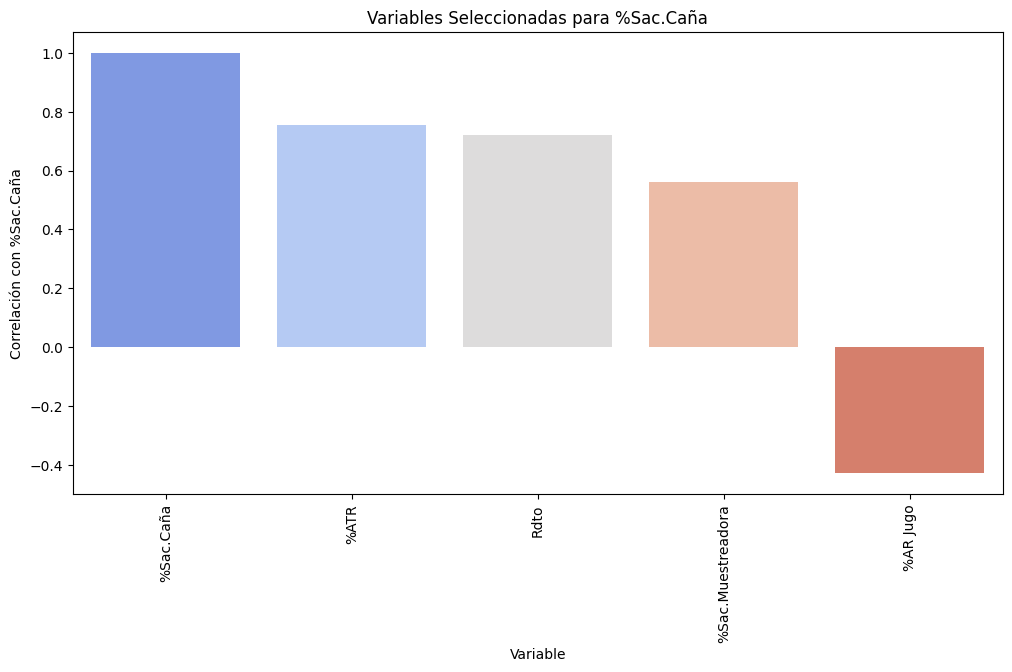

In [ ]:
# Visualización de las variables seleccionadas
plt.figure(figsize=(12, 6))
sns.barplot(x=selected_features_tch, y=corr_tch[selected_features_tch], palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Variable")
plt.ylabel("Correlación con TCH")
plt.title("Variables Seleccionadas para TCH")
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x=selected_features_sac_cana, y=corr_sac_cana[selected_features_sac_cana], palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Variable")
plt.ylabel("Correlación con %Sac.Caña")
plt.title("Variables Seleccionadas para %Sac.Caña")
plt.show()



Factor de Inflación de Varianza (VIF):
              Variable         VIF
0                 TCH  506.117557
1                 TAH  609.733800
2                TCHM  409.313307
3              KATRHM  514.107035
4                TAHM  890.505861
5         TonUltCorte    2.575080
6           %Sac.Caña  405.291857
7                %ATR  730.842940
8                Rdto  624.927900
9   %Sac.Muestreadora  151.362377
10           %AR Jugo   12.546299


<ipython-input-61-a962849ea2fa>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=vif_data["Variable"], y=vif_data["VIF"], palette="coolwarm")


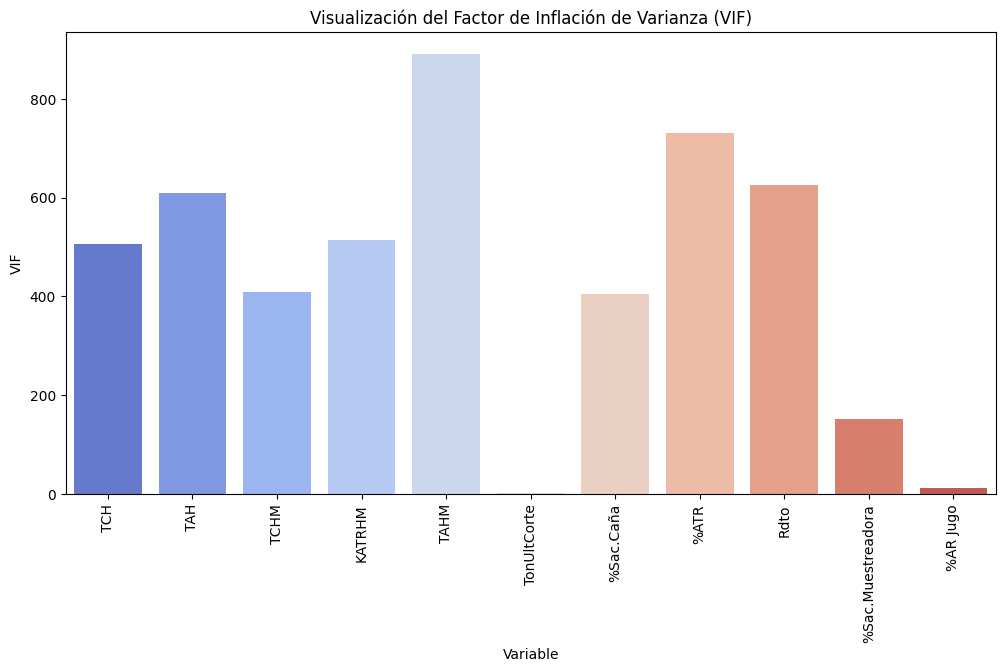

In [ ]:
# Factor de Inflación de Varianza (VIF)
vif_data = pd.DataFrame()
all_features = selected_features_tch + selected_features_sac_cana
# Remove duplicates from the combined feature list
all_features = list(dict.fromkeys(all_features))
vif_data["Variable"] = all_features

# Replace infinite values with NaN
df_model_vif = df_model[all_features].replace([np.inf, -np.inf], np.nan)

# Drop rows with NaN values
df_model_vif = df_model_vif.dropna()

vif_data["VIF"] = [variance_inflation_factor(df_model_vif.values, i)
                   for i in range(len(vif_data["Variable"]))]
print("\nFactor de Inflación de Varianza (VIF):\n", vif_data)

# Visualización del VIF
plt.figure(figsize=(12, 6))
sns.barplot(x=vif_data["Variable"], y=vif_data["VIF"], palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Variable")
plt.ylabel("VIF")
plt.title("Visualización del Factor de Inflación de Varianza (VIF)")
plt.show()

In [ ]:
# Modelo de Regresión Lineal para predecir TCH y %Sac.Caña

# Separar variables independientes y dependientes
X_tch = df_model[selected_features_tch].drop(columns=["TCH"], errors="ignore")
y_tch = df_model["TCH"]

X_sac_cana = df_model[selected_features_sac_cana].drop(columns=["%Sac.Caña"], errors="ignore")
y_sac_cana = df_model["%Sac.Caña"]

In [ ]:
# Dividir en conjuntos de entrenamiento y prueba
X_tch_train, X_tch_test, y_tch_train, y_tch_test = train_test_split(X_tch, y_tch, test_size=0.2, random_state=42)
X_sac_cana_train, X_sac_cana_test, y_sac_cana_train, y_sac_cana_test = train_test_split(X_sac_cana, y_sac_cana, test_size=0.2, random_state=42)

In [ ]:
# Ajustar modelo de regresión lineal para TCH
reg_tch = LinearRegression()
reg_tch.fit(X_tch_train, y_tch_train)
y_tch_pred = reg_tch.predict(X_tch_test)

In [ ]:
# Evaluar modelo para TCH
print("\nEvaluación del modelo de Regresión Lineal para TCH:")
print("R²:", r2_score(y_tch_test, y_tch_pred))
print("MAE:", mean_absolute_error(y_tch_test, y_tch_pred))
# Calculate RMSE manually if squared parameter is not supported
rmse = np.sqrt(mean_squared_error(y_tch_test, y_tch_pred))
print("RMSE:", rmse)


Evaluación del modelo de Regresión Lineal para TCH:
R²: -12.271056582026585
MAE: 117.13942440710863
RMSE: 121.3805088218927


In [ ]:
# Ajustar modelo de regresión lineal para %Sac.Caña
reg_sac_cana = LinearRegression()
reg_sac_cana.fit(X_sac_cana_train, y_sac_cana_train)
y_sac_cana_pred = reg_sac_cana.predict(X_sac_cana_test)

In [ ]:
# Evaluar modelo para %Sac.Caña
print("\nEvaluación del modelo de Regresión Lineal para %Sac.Caña:")
print("R²:", r2_score(y_sac_cana_test, y_sac_cana_pred))
print("MAE:", mean_absolute_error(y_sac_cana_test, y_sac_cana_pred))
# Calculate RMSE manually since 'squared' might not be supported
rmse = np.sqrt(mean_squared_error(y_sac_cana_test, y_sac_cana_pred))
print("RMSE:", rmse)


Evaluación del modelo de Regresión Lineal para %Sac.Caña:
R²: 0.7990725287792824
MAE: 0.3002337228563677
RMSE: 0.49784691638412387


In [ ]:
# Modelos de Regresión Regularizada (Lasso y Ridge) para reducir la multicolinealidad
from sklearn.linear_model import Ridge, Lasso

# Ajustar modelo Ridge para TCH
ridge_tch = Ridge(alpha=100000)
ridge_tch.fit(X_tch_train, y_tch_train)
y_tch_ridge_pred = ridge_tch.predict(X_tch_test)

# Ajustar modelo Lasso para TCH
lasso_tch = Lasso(alpha=10)
lasso_tch.fit(X_tch_train, y_tch_train)
y_tch_lasso_pred = lasso_tch.predict(X_tch_test)

print("Evaluación del modelo Ridge para TCH:")
print("R²:", r2_score(y_tch_test, y_tch_ridge_pred))
print("MAE:", mean_absolute_error(y_tch_test, y_tch_ridge_pred))
# If your scikit-learn is older than 0.24, remove 'squared=False' or upgrade to 0.24+
print("RMSE:", np.sqrt(mean_squared_error(y_tch_test, y_tch_ridge_pred)))

print("Evaluación del modelo Lasso para TCH:")
print("R²:", r2_score(y_tch_test, y_tch_lasso_pred))
print("MAE:", mean_absolute_error(y_tch_test, y_tch_lasso_pred))
# If your scikit-learn is older than 0.24, remove 'squared=False' or upgrade to 0.24+
print("RMSE:", np.sqrt(mean_squared_error(y_tch_test, y_tch_lasso_pred)))

# Ajustar modelo Ridge para %Sac.Caña
ridge_sac_cana = Ridge(alpha=1.0)
ridge_sac_cana.fit(X_sac_cana_train, y_sac_cana_train)
y_sac_cana_ridge_pred = ridge_sac_cana.predict(X_sac_cana_test)

# Ajustar modelo Lasso para %Sac.Caña  # This line was added
lasso_sac_cana = Lasso(alpha=0.1)   # This line was added
lasso_sac_cana.fit(X_sac_cana_train, y_sac_cana_train) # This line was added
y_sac_cana_lasso_pred = lasso_sac_cana.predict(X_sac_cana_test) # This line was added


# Evaluar modelos para %Sac.Caña
print("Evaluación del modelo Ridge para %Sac.Caña:")
print("R²:", r2_score(y_sac_cana_test, y_sac_cana_ridge_pred))
print("MAE:", mean_absolute_error(y_sac_cana_test, y_sac_cana_ridge_pred))
# If your scikit-learn is older than 0.24, remove 'squared=False' or upgrade to 0.24+
print("RMSE:", np.sqrt(mean_squared_error(y_sac_cana_test, y_sac_cana_ridge_pred)))

print("Evaluación del modelo Lasso para %Sac.Caña:")
print("R²:", r2_score(y_sac_cana_test, y_sac_cana_lasso_pred))
print("MAE:", mean_absolute_error(y_sac_cana_test, y_sac_cana_lasso_pred))
# If your scikit-learn is older than 0.24, remove 'squared=False' or upgrade to 0.24+
print("RMSE:", np.sqrt(mean_squared_error(y_sac_cana_test, y_sac_cana_lasso_pred)))

Evaluación del modelo Ridge para TCH:
R²: 0.7846186598773109
MAE: 11.515179914743635
RMSE: 15.463230893393673
Evaluación del modelo Lasso para TCH:
R²: 0.8233491180745001
MAE: 10.289514404782269
RMSE: 14.004064690541197
Evaluación del modelo Ridge para %Sac.Caña:
R²: 0.7990730732684477
MAE: 0.3001972501901599
RMSE: 0.49784624183117704
Evaluación del modelo Lasso para %Sac.Caña:
R²: 0.752737545073255
MAE: 0.3475924456156377
RMSE: 0.5522748300243685
